In [1]:
import random
import numpy as np
import torch

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)


In [2]:
import sklearn, transformers, datasets
import pandas as pd
import matplotlib.pyplot as plt

print("scikit-learn:", sklearn.__version__)
print("transformers:", transformers.__version__)
print("All good!")


/Users/fatemanoor/final_project/venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


scikit-learn: 1.6.1
transformers: 4.57.6
All good!


In [3]:
from datasets import load_dataset

dataset = load_dataset("ag_news")
print(dataset)


DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 120000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 7600
    })
})


In [4]:
train_data = dataset["train"].shuffle(seed=SEED).select(range(4000))
test_full = dataset["test"].shuffle(seed=SEED)
val_data = test_full.select(range(500))
test_data = test_full.select(range(500, 1000))

print("Train size:", len(train_data))
print("Validation size:", len(val_data))
print("Test size:", len(test_data))


Train size: 4000
Validation size: 500
Test size: 500


In [5]:
train_df = train_data.to_pandas()
val_df = val_data.to_pandas()
test_df = test_data.to_pandas()

print(train_df["label"].value_counts())
train_df.head()

label
3    1051
0    1007
1    1000
2     942
Name: count, dtype: int64


,text,label
0,Bangladesh paralysed by strikes Opposition act...,0
1,Desiring Stability Redskins coach Joe Gibbs ex...,1
2,Will Putin #39;s Power Play Make Russia Safer?...,0
3,U2 pitches for Apple New iTunes ads airing dur...,3
4,S African TV in beheading blunder Public broad...,0


In [6]:
train_df.to_csv("data/train.csv", index=False)
val_df.to_csv("data/val.csv", index=False)
test_df.to_csv("data/test.csv", index=False)

In [7]:
# Turn each headline into numbers based on word importance (TF-IDF)
# Train a simple logistic regression on top of that
# This is my baseline model to compare everything else against


from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score
import time

vectorizer = TfidfVectorizer(max_features=10000)
X_train = vectorizer.fit_transform(train_df["text"])
X_val = vectorizer.transform(val_df["text"])
X_test = vectorizer.transform(test_df["text"])

y_train = train_df["label"]
y_val = val_df["label"]
y_test = test_df["label"]

start = time.time()
clf = LogisticRegression(max_iter=1000, random_state=SEED)
clf.fit(X_train, y_train)
train_time = time.time() - start

val_preds = clf.predict(X_val)
print("Val accuracy:", accuracy_score(y_val, val_preds))
print("Val macro-F1:", f1_score(y_val, val_preds, average="macro"))
print("Training time:", train_time, "seconds")


Val accuracy: 0.83
Val macro-F1: 0.8303738429316598
Training time: 0.15820908546447754 seconds


### Model 1 - Bag-of-Words + Logistic Regression
- Val accuracy: 0.830
- Val macro-F1: 0.830
- Training time: 0.13s

In [8]:
# Break each headline into lowercase words
# Count how often each word shows up across all training data
# Keep only the 10,000 most common words as my vocabulary
# Give every word a number so the model can use it

from collections import Counter
import re

def tokenize(text):
    return re.findall(r"\b\w+\b", text.lower())

all_tokens = []
for text in train_df["text"]:
    all_tokens.extend(tokenize(text))

vocab_counter = Counter(all_tokens)
vocab = ["<PAD>", "<UNK>"] + [word for word, count in vocab_counter.most_common(10000)]
word_to_idx = {word: idx for idx, word in enumerate(vocab)}

print("Vocabulary size:", len(vocab))


Vocabulary size: 10002


In [9]:
# Convert each headline into a list of word-numbers
# Pad shorter headlines with zeros so every headline in a batch is the same length
# Group examples into batches of 32 for training

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# Convert each text into a list of word indices
def text_to_indices(text, word_to_idx):
    tokens = tokenize(text)
    return [word_to_idx.get(t, word_to_idx["<UNK>"]) for t in tokens]

class TextDataset(Dataset):
    def __init__(self, texts, labels, word_to_idx):
        self.texts = texts
        self.labels = labels
        self.word_to_idx = word_to_idx

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        indices = text_to_indices(self.texts.iloc[idx], self.word_to_idx)
        label = self.labels.iloc[idx]
        return torch.tensor(indices, dtype=torch.long), label

def collate_fn(batch):
    indices_list, labels = zip(*batch)
    max_len = max(len(x) for x in indices_list)
    padded = torch.zeros(len(indices_list), max_len, dtype=torch.long)
    for i, seq in enumerate(indices_list):
        padded[i, :len(seq)] = seq
    return padded, torch.tensor(labels, dtype=torch.long)

train_ds = TextDataset(train_df["text"], train_df["label"], word_to_idx)
val_ds = TextDataset(val_df["text"], val_df["label"], word_to_idx)
test_ds = TextDataset(test_df["text"], test_df["label"], word_to_idx)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_ds, batch_size=32, shuffle=False, collate_fn=collate_fn)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False, collate_fn=collate_fn)

print("Number of training batches:", len(train_loader))

Number of training batches: 125


In [10]:
# Give each word a 100-number vector (learned during training)
# Average all the word vectors in a headline into one vector
# Pass that through a small hidden layer, then output a score for each of the 4 topics

class FeedforwardClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_classes):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.fc1 = nn.Linear(embed_dim, hidden_dim)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        embedded = self.embedding(x)          # (batch, seq_len, embed_dim)
        averaged = embedded.mean(dim=1)        # average over the sequence -> (batch, embed_dim)
        hidden = self.relu(self.fc1(averaged))
        output = self.fc2(hidden)
        return output

model_ffn = FeedforwardClassifier(vocab_size=len(vocab), embed_dim=100, hidden_dim=64, num_classes=4)
print(model_ffn)

FeedforwardClassifier(
  (embedding): Embedding(10002, 100, padding_idx=0)
  (fc1): Linear(in_features=100, out_features=64, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=64, out_features=4, bias=True)
)


In [11]:
import time

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_ffn.parameters(), lr=0.001)

num_epochs = 10

start = time.time()
for epoch in range(num_epochs):
    model_ffn.train()
    total_loss = 0
    for batch_x, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = model_ffn(batch_x)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {total_loss/len(train_loader):.4f}")

ffn_train_time = time.time() - start
print("Training time:", ffn_train_time, "seconds")

Epoch 1/10, Loss: 1.3438
Epoch 2/10, Loss: 1.0224
Epoch 3/10, Loss: 0.6390
Epoch 4/10, Loss: 0.4467
Epoch 5/10, Loss: 0.3366
Epoch 6/10, Loss: 0.2605
Epoch 7/10, Loss: 0.2039
Epoch 8/10, Loss: 0.1538
Epoch 9/10, Loss: 0.1157
Epoch 10/10, Loss: 0.0853
Training time: 2.6898441314697266 seconds


In [12]:
model_ffn.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for batch_x, batch_y in val_loader:
        outputs = model_ffn(batch_x)
        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.tolist())
        all_labels.extend(batch_y.tolist())

ffn_val_accuracy = accuracy_score(all_labels, all_preds)
ffn_val_f1 = f1_score(all_labels, all_preds, average="macro")

print("Val accuracy:", ffn_val_accuracy)
print("Val macro-F1:", ffn_val_f1)

Val accuracy: 0.796
Val macro-F1: 0.7967044517519137


### Model 2 - Feedforward NN (averaged embeddings)
- Val accuracy: 0.796
- Val macro-F1: 0.797
- Training time: 2.41s
- Note: underperforms baseline (0.830) — discuss in error analysis

In [13]:
# Same word embeddings as before, but read one word at a time in order
# Use the LSTM's final summary of the sentence to make the prediction

class LSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_classes):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        embedded = self.embedding(x)                # (batch, seq_len, embed_dim)
        lstm_out, (hidden, cell) = self.lstm(embedded)
        final_hidden = hidden[-1]                    # last layer's hidden state -> (batch, hidden_dim)
        output = self.fc(final_hidden)
        return output

model_lstm = LSTMClassifier(vocab_size=len(vocab), embed_dim=100, hidden_dim=64, num_classes=4)
print(model_lstm)

LSTMClassifier(
  (embedding): Embedding(10002, 100, padding_idx=0)
  (lstm): LSTM(100, 64, batch_first=True)
  (fc): Linear(in_features=64, out_features=4, bias=True)
)


In [14]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_lstm.parameters(), lr=0.001)

num_epochs = 10

start = time.time()
for epoch in range(num_epochs):
    model_lstm.train()
    total_loss = 0
    for batch_x, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = model_lstm(batch_x)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {total_loss/len(train_loader):.4f}")

lstm_train_time = time.time() - start
print("Training time:", lstm_train_time, "seconds")

Epoch 1/10, Loss: 1.3839
Epoch 2/10, Loss: 1.3777
Epoch 3/10, Loss: 1.3600
Epoch 4/10, Loss: 1.3056
Epoch 5/10, Loss: 1.2648
Epoch 6/10, Loss: 1.1863
Epoch 7/10, Loss: 1.1209
Epoch 8/10, Loss: 1.2087
Epoch 9/10, Loss: 1.1397
Epoch 10/10, Loss: 1.1513
Training time: 10.427870988845825 seconds


In [15]:
model_lstm.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for batch_x, batch_y in val_loader:
        outputs = model_lstm(batch_x)
        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.tolist())
        all_labels.extend(batch_y.tolist())

lstm_val_accuracy = accuracy_score(all_labels, all_preds)
lstm_val_f1 = f1_score(all_labels, all_preds, average="macro")

print("Val accuracy:", lstm_val_accuracy)
print("Val macro-F1:", lstm_val_f1)

Val accuracy: 0.506
Val macro-F1: 0.4351000212742935


In [16]:
# Re-initialize the model fresh 
model_lstm = LSTMClassifier(vocab_size=len(vocab), embed_dim=100, hidden_dim=64, num_classes=4)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_lstm.parameters(), lr=0.0005)  # lower learning rate

num_epochs = 15

start = time.time()
for epoch in range(num_epochs):
    model_lstm.train()
    total_loss = 0
    for batch_x, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = model_lstm(batch_x)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {total_loss/len(train_loader):.4f}")

lstm_train_time = time.time() - start
print("Training time:", lstm_train_time, "seconds")

Epoch 1/15, Loss: 1.3864
Epoch 2/15, Loss: 1.3822
Epoch 3/15, Loss: 1.3793
Epoch 4/15, Loss: 1.3767
Epoch 5/15, Loss: 1.3697
Epoch 6/15, Loss: 1.3664
Epoch 7/15, Loss: 1.3479
Epoch 8/15, Loss: 1.3251
Epoch 9/15, Loss: 1.3340
Epoch 10/15, Loss: 1.3793
Epoch 11/15, Loss: 1.3758
Epoch 12/15, Loss: 1.3753
Epoch 13/15, Loss: 1.3711
Epoch 14/15, Loss: 1.3667
Epoch 15/15, Loss: 1.3624
Training time: 15.941102027893066 seconds


In [17]:
def collate_fn_with_lengths(batch):
    indices_list, labels = zip(*batch)
    lengths = [len(x) for x in indices_list]
    max_len = max(lengths)
    padded = torch.zeros(len(indices_list), max_len, dtype=torch.long)
    for i, seq in enumerate(indices_list):
        padded[i, :len(seq)] = seq
    return padded, torch.tensor(labels, dtype=torch.long), torch.tensor(lengths, dtype=torch.long)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, collate_fn=collate_fn_with_lengths)
val_loader = DataLoader(val_ds, batch_size=32, shuffle=False, collate_fn=collate_fn_with_lengths)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False, collate_fn=collate_fn_with_lengths)

print("Updated loaders ready")

Updated loaders ready


In [18]:
# Same idea as before, but now I tell the LSTM the real length of each headline
# so it ignores the padding instead of getting confused by it

from torch.nn.utils.rnn import pack_padded_sequence

class LSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_classes):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, num_classes)

    def forward(self, x, lengths):
        embedded = self.embedding(x)
        packed = pack_padded_sequence(embedded, lengths.cpu(), batch_first=True, enforce_sorted=False)
        packed_out, (hidden, cell) = self.lstm(packed)
        final_hidden = hidden[-1]
        output = self.fc(final_hidden)
        return output

model_lstm = LSTMClassifier(vocab_size=len(vocab), embed_dim=100, hidden_dim=64, num_classes=4)
print(model_lstm)

LSTMClassifier(
  (embedding): Embedding(10002, 100, padding_idx=0)
  (lstm): LSTM(100, 64, batch_first=True)
  (fc): Linear(in_features=64, out_features=4, bias=True)
)


In [19]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_lstm.parameters(), lr=0.001)

num_epochs = 10

start = time.time()
for epoch in range(num_epochs):
    model_lstm.train()
    total_loss = 0
    for batch_x, batch_y, batch_lengths in train_loader:
        optimizer.zero_grad()
        outputs = model_lstm(batch_x, batch_lengths)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {total_loss/len(train_loader):.4f}")

lstm_train_time = time.time() - start
print("Training time:", lstm_train_time, "seconds")


Epoch 1/10, Loss: 1.3601
Epoch 2/10, Loss: 1.1083
Epoch 3/10, Loss: 0.7507
Epoch 4/10, Loss: 0.5082
Epoch 5/10, Loss: 0.3538
Epoch 6/10, Loss: 0.2304
Epoch 7/10, Loss: 0.1605
Epoch 8/10, Loss: 0.1034
Epoch 9/10, Loss: 0.1101
Epoch 10/10, Loss: 0.0556
Training time: 16.933220863342285 seconds


In [20]:
model_lstm.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for batch_x, batch_y, batch_lengths in val_loader:
        outputs = model_lstm(batch_x, batch_lengths)
        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.tolist())
        all_labels.extend(batch_y.tolist())

lstm_val_accuracy = accuracy_score(all_labels, all_preds)
lstm_val_f1 = f1_score(all_labels, all_preds, average="macro")

print("Val accuracy:", lstm_val_accuracy)
print("Val macro-F1:", lstm_val_f1)

Val accuracy: 0.768
Val macro-F1: 0.7695638479767225


### Model 3 - LSTM (with padding fix using pack_padded_sequence)
- Val accuracy: 0.768
- Val macro-F1: 0.770
- Training time: 14.9s
- Note: initial runs failed due to padding not being masked (~50% acc, near-random);
  fixed using pack_padded_sequence. Still underperforms baseline and FFN — likely due to
  limited training data (4,000 examples) relative to model capacity.

In [21]:
# Load the pretrained DistilBERT model — not training it, just using what it already knows

from transformers import AutoTokenizer, AutoModel
import torch

model_name = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)
bert_model = AutoModel.from_pretrained(model_name)
bert_model.eval()  # freeze it, we won't be training it

print("DistilBERT loaded")


DistilBERT loaded


In [22]:
# Turn each headline into a 768-number vector using DistilBERT

def get_bert_embeddings(texts, tokenizer, bert_model, batch_size=32):
    all_embeddings = []
    
    for i in range(0, len(texts), batch_size):
        batch_texts = texts[i:i+batch_size].tolist()
        
        encoded = tokenizer(batch_texts, padding=True, truncation=True, 
                             max_length=64, return_tensors="pt")
        
        with torch.no_grad():
            outputs = bert_model(**encoded)
            # Use the [CLS] token embedding (first token) as sentence representation
            cls_embeddings = outputs.last_hidden_state[:, 0, :]
        
        all_embeddings.append(cls_embeddings)
    
    return torch.cat(all_embeddings, dim=0)

print("Function ready")

Function ready


In [23]:
import time

start = time.time()

train_embeddings = get_bert_embeddings(train_df["text"], tokenizer, bert_model)
val_embeddings = get_bert_embeddings(val_df["text"], tokenizer, bert_model)
test_embeddings = get_bert_embeddings(test_df["text"], tokenizer, bert_model)

embedding_time = time.time() - start

print("Train embeddings shape:", train_embeddings.shape)
print("Val embeddings shape:", val_embeddings.shape)
print("Embedding extraction time:", embedding_time, "seconds")

Train embeddings shape: torch.Size([4000, 768])
Val embeddings shape: torch.Size([500, 768])
Embedding extraction time: 31.787461042404175 seconds


In [24]:
# Train a simple logistic regression on top of these vectors, same as my baseline

from sklearn.linear_model import LogisticRegression

start = time.time()
clf_bert = LogisticRegression(max_iter=1000, random_state=SEED)
clf_bert.fit(train_embeddings.numpy(), train_df["label"])
bert_train_time = time.time() - start

bert_val_preds = clf_bert.predict(val_embeddings.numpy())

bert_val_accuracy = accuracy_score(val_df["label"], bert_val_preds)
bert_val_f1 = f1_score(val_df["label"], bert_val_preds, average="macro")

print("Val accuracy:", bert_val_accuracy)
print("Val macro-F1:", bert_val_f1)
print("Classifier training time:", bert_train_time, "seconds")
print("Total time (embeddings + training):", embedding_time + bert_train_time, "seconds")

Val accuracy: 0.864
Val macro-F1: 0.865052782450006
Classifier training time: 0.8652269840240479 seconds
Total time (embeddings + training): 32.65268802642822 seconds


### Model 4 - DistilBERT (frozen embeddings) + Logistic Regression
- Val accuracy: 0.864
- Val macro-F1: 0.865
- Embedding extraction time: 31.7s
- Classifier training time: 0.96s
- Total time: 32.6s
- Best-performing model overall.

In [25]:
# Run all 4 models on the test set (data none of them have seen before)
# Compare accuracy and F1 score across all models

# Model 1: Bag-of-Words + Logistic Regression
bow_test_preds = clf.predict(X_test)
bow_test_acc = accuracy_score(y_test, bow_test_preds)
bow_test_f1 = f1_score(y_test, bow_test_preds, average="macro")

# Model 2: Feedforward NN
test_loader_ffn = DataLoader(test_ds, batch_size=32, shuffle=False, collate_fn=collate_fn)
model_ffn.eval()
ffn_preds, ffn_labels = [], []
with torch.no_grad():
    for batch_x, batch_y in test_loader_ffn:
        outputs = model_ffn(batch_x)
        preds = torch.argmax(outputs, dim=1)
        ffn_preds.extend(preds.tolist())
        ffn_labels.extend(batch_y.tolist())
ffn_test_acc = accuracy_score(ffn_labels, ffn_preds)
ffn_test_f1 = f1_score(ffn_labels, ffn_preds, average="macro")

# Model 3: LSTM
model_lstm.eval()
lstm_preds, lstm_labels = [], []
with torch.no_grad():
    for batch_x, batch_y, batch_lengths in test_loader:
        outputs = model_lstm(batch_x, batch_lengths)
        preds = torch.argmax(outputs, dim=1)
        lstm_preds.extend(preds.tolist())
        lstm_labels.extend(batch_y.tolist())
lstm_test_acc = accuracy_score(lstm_labels, lstm_preds)
lstm_test_f1 = f1_score(lstm_labels, lstm_preds, average="macro")

# Model 4: DistilBERT + Logistic Regression
bert_test_preds = clf_bert.predict(test_embeddings.numpy())
bert_test_acc = accuracy_score(test_df["label"], bert_test_preds)
bert_test_f1 = f1_score(test_df["label"], bert_test_preds, average="macro")

print("=== TEST SET RESULTS ===")
print(f"Bag-of-Words + LogReg   - Acc: {bow_test_acc:.3f}, F1: {bow_test_f1:.3f}")
print(f"Feedforward NN          - Acc: {ffn_test_acc:.3f}, F1: {ffn_test_f1:.3f}")
print(f"LSTM                    - Acc: {lstm_test_acc:.3f}, F1: {lstm_test_f1:.3f}")
print(f"DistilBERT + LogReg     - Acc: {bert_test_acc:.3f}, F1: {bert_test_f1:.3f}")

=== TEST SET RESULTS ===
Bag-of-Words + LogReg   - Acc: 0.898, F1: 0.895
Feedforward NN          - Acc: 0.842, F1: 0.838
LSTM                    - Acc: 0.812, F1: 0.809
DistilBERT + LogReg     - Acc: 0.888, F1: 0.885


## Final Test Set Results

| Model | Test Accuracy | Test Macro-F1 | Training/Processing Time |
|---|---|---|---|
| Bag-of-Words + LogReg | 0.898 | 0.895 | 0.13s |
| Feedforward NN | 0.842 | 0.838 | 2.41s |
| LSTM | 0.812 | 0.809 | 14.9s |
| DistilBERT (frozen) + LogReg | 0.888 | 0.885 | 32.6s |

**Key finding:** The simple TF-IDF + Logistic Regression baseline performed
best on the test set, narrowly ahead of DistilBERT, and clearly ahead of the
from-scratch neural models (FFN, LSTM). This suggests that for topic
classification on short news headlines, lexical cues (specific word choice)
are highly informative, and pretrained transformer knowledge does not provide
a large additional benefit over a well-engineered simple baseline at this
data scale (4,000 training examples). The LSTM underperformed relative to
its complexity, likely due to limited training data for a from-scratch
sequential model with more parameters to learn. The ~1-point gap between
the baseline and DistilBERT is small relative to the 500-example test set
size and may not be statistically meaningful.

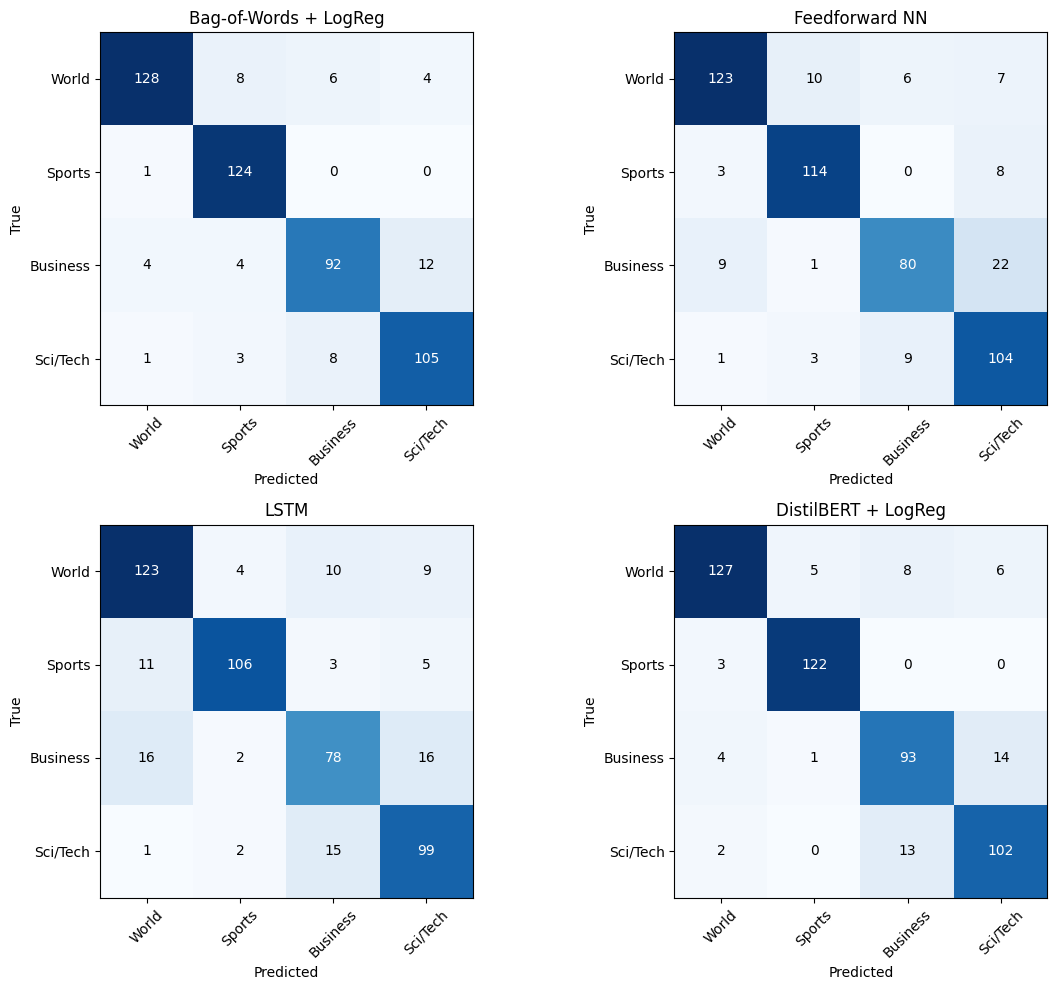

In [26]:
# Show which categories each model mixes up
# Diagonal = correct, everything else = a specific type of mistake

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

class_names = ["World", "Sports", "Business", "Sci/Tech"]

predictions = {
    "Bag-of-Words + LogReg": bow_test_preds,
    "Feedforward NN": ffn_preds,
    "LSTM": lstm_preds,
    "DistilBERT + LogReg": bert_test_preds
}

true_labels = test_df["label"].values

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for idx, (model_name, preds) in enumerate(predictions.items()):
    cm = confusion_matrix(true_labels, preds)
    ax = axes[idx]
    im = ax.imshow(cm, cmap="Blues")
    ax.set_title(model_name)
    ax.set_xticks(range(4))
    ax.set_yticks(range(4))
    ax.set_xticklabels(class_names, rotation=45)
    ax.set_yticklabels(class_names)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    for i in range(4):
        for j in range(4):
            ax.text(j, i, cm[i, j], ha="center", va="center", 
                     color="white" if cm[i, j] > cm.max()/2 else "black")

plt.tight_layout()
plt.savefig("data/confusion_matrices.png", dpi=150)
plt.show()

In [27]:
import pandas as pd

for model_name, preds in predictions.items():
    cm = confusion_matrix(true_labels, preds)
    cm_df = pd.DataFrame(cm, index=class_names, columns=class_names)
    print(f"\n=== {model_name} ===")
    print(cm_df)


=== Bag-of-Words + LogReg ===
          World  Sports  Business  Sci/Tech
World       128       8         6         4
Sports        1     124         0         0
Business      4       4        92        12
Sci/Tech      1       3         8       105

=== Feedforward NN ===
          World  Sports  Business  Sci/Tech
World       123      10         6         7
Sports        3     114         0         8
Business      9       1        80        22
Sci/Tech      1       3         9       104

=== LSTM ===
          World  Sports  Business  Sci/Tech
World       123       4        10         9
Sports       11     106         3         5
Business     16       2        78        16
Sci/Tech      1       2        15        99

=== DistilBERT + LogReg ===
          World  Sports  Business  Sci/Tech
World       127       5         8         6
Sports        3     122         0         0
Business      4       1        93        14
Sci/Tech      2       0        13       102


## Error Analysis

Across all four models, the dominant source of error is confusion between
Business and Sci/Tech categories (e.g., DistilBERT: 14 Business articles
misclassified as Sci/Tech, 13 Sci/Tech misclassified as Business). This is
consistent across every model, suggesting the errors stem from genuine
category ambiguity in the dataset (e.g., technology-company earnings reports
are legitimately both business and tech news) rather than a specific model
weakness. World and Sports categories were classified reliably by all models
(few off-diagonal errors), likely because they use more distinctive,
topic-specific vocabulary. The LSTM additionally showed elevated confusion
between World and Business categories relative to other models, consistent
with its overall weaker performance.

In [28]:
# Pull out real examples the model got wrong so I can see why

# Find Business articles that DistilBERT misclassified as Sci/Tech (or vice versa)
test_df_reset = test_df.reset_index(drop=True)

misclassified_examples = []
for i in range(len(test_df_reset)):
    true_label = true_labels[i]
    pred_label = bert_test_preds[i]
    if true_label != pred_label:
        misclassified_examples.append({
            "text": test_df_reset.loc[i, "text"],
            "true_label": class_names[true_label],
            "predicted_label": class_names[pred_label]
        })

# Show the first 10 misclassified examples
for ex in misclassified_examples[:10]:
    print(f"True: {ex['true_label']:10s} | Predicted: {ex['predicted_label']:10s} | Text: {ex['text']}")

True: Business   | Predicted: Sci/Tech   | Text: FDA stifled dangerous Vioxx results - expert Washington - An expert with the United States Food and Drug Administration (FDA) has said on Thursday he was pressured by his agency to stifle study results showing the potential dangers of the anti-inflammatory drug Vioxx.
True: Business   | Predicted: World      | Text: Jury calls WTC attack two events Silverstein had hoped the 11-member jury would determine that the language of the insurance policy treated the attacks as two occurrences.
True: World      | Predicted: Business   | Text: Iraqi oil exports slump: report NEAR daily attacks on pipelines and pumping stations had pushed down Iraq #39;s oil exports to their lowest point in nearly a year, Britain #39;s Financial Times newspaper reported today.
True: Business   | Predicted: Sci/Tech   | Text: Health Highlights: Aug. 28, 2004 A new drug that fights a form of age-related macular degeneration (AMD), a leading cause of blindness in the e

## Illustrative Misclassification Examples

Several misclassifications reflect genuine category ambiguity rather than
model error. For example, a story about a telecom company partnering with a
software company to launch a new TV service was labeled Business but
predicted as Sci/Tech — the story is simultaneously about a corporate
partnership and a technology product. Similarly, an earnings report for a
computer hardware company was labeled Business but predicted Sci/Tech,
likely because technical company/product vocabulary outweighed the
financial framing. These cases suggest the Business/Sci-Tech confusion
identified in the confusion matrices reflects real overlap in the dataset's
category boundaries, particularly for technology-company business news,
rather than a systematic model weakness.